# Candlestick patterns for one stock (using yfinance)

This notebook demonstrates candlestick pattern analysis using data downloaded directly from yfinance. It follows the same methodology as the original notebook but uses free data sources instead of premium WRDS/CRSP data.


## Load libraries

At first, we will load up some dependencies that we will make use of later on. We follow the convention of naming them a standard alias for easier handling.


In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import talib
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.feature_selection import RFECV
from IPython.display import Image
import inspect
from pathlib import Path

from BSquant import process_data
from BSquant import cs_pattern_recognition
from BSquant import cs_performance
from BSquant import plot_cs_performance
from BSquant import compute_trading_strategy_performance

pd.set_option("display.max_columns", None)
%load_ext autoreload
%autoreload 2


/Users/kobesin/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# What is a candlestick and what are candlestick patterns?

This section aims at briefly describing what candlesticks are, so we bring everyone up to speed regarding this graphical representation of price data.


## Anatomy of a candlestick (aka Japanese candlesticks)

A candlestick summarizes the four key price levels of a security within a specific time interval, such as 1 minute, 1 hour, or more commonly, 1 day. Candlesticks can also represent price data over various different intervals, such as 5 minutes, 4 hours, or any other specified duration.

These price levels include the opening price, highest price, lowest price, and closing price within the specific time interval. Candlesticks are typically colored green when the `close price > open price`, indicating a price increase during the interval, which defines a `bullish candle`. Conversely, they are colored red when the `close price < open price`, indicating a price decrease, which defines a `bearish candle`. The area between the opening and closing prices is known as the body of the candlestick.

A candlestick can also feature wicks above and below the body, known as the `upper wick` and `lower wick`, respectively. The lower wick of a bullish candle represents the distance between the lowest price and the opening price. In case of a bearish candle, it is the distance between the lowest price and the closing price. Conversely, the upper wick of a bullish candle illustrates the range from the closing price to the highest price, or, for a bearish candle, the distance from the opening price to the highest price.

Price summaries that adhere to the described structure are known as `Japanese candlesticks`. This naming traces back to their origins in Japan, where they were first developed. In contrast, practitioners in Europe and the United States commonly use a concept known as a price bar. Unlike candlesticks, price bars do not visually differentiate the market's mood (i.e., bullish or bearish) through a colored body. Instead, they indicate the opening and closing prices with markers positioned to the left and right, respectively. This makes price bars less graphically intuitive for interpreting market movements.

The image below illustrates the concepts explained.


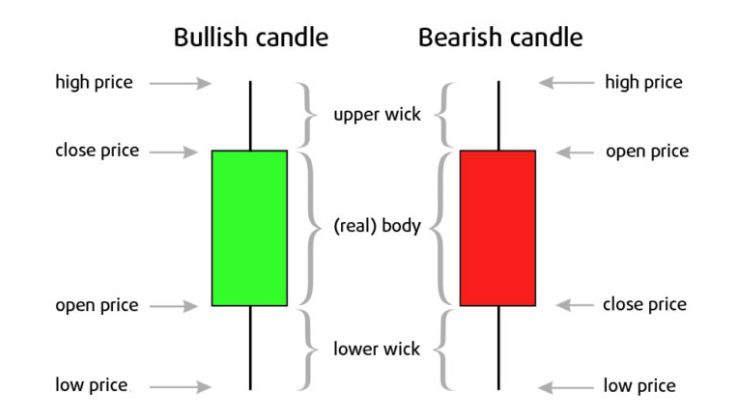

In [2]:
Image(filename="./../figures/candlestick_anatomy.png")


[Source: https://tradingcryptocourse.com/free/technical-analysis-candlesticks/]


## Candlestick patterns

Two or more candlesticks may form what is known as a candlestick pattern. The question arises: Why are these patterns significant? According to the efficient market hypothesis, they should not be. This theory suggests that all information affecting the price of an equity in a frictionless market is already accounted for in the price, based on the consensus between buyers and sellers at any moment the market is open. Crucially, this would mean prices follow a `Markov Process`, with the best predictor for the price at `t+1` being the price at `t`. Candlestick analysis, however, challenges this notion. It posits that certain patterns can predict price movements in the subsequent time interval, indicating that prices may not solely rely on the most recent information, but that, in fact, history repeats itself following specific patterns.

This project does not seek to challenge the efficient market hypothesis directly. Rather, our aim is to analyze a substantial volume of financial data from liquid stocks within the `S&P 500`, sourced from a reliable provider, to determine if there is statistical evidence supporting the hypothesis of those following candlestick analysis. Our null hypothesis posits that the likelihood of a positive intraday return at `t+1` is equal to the likelihood of a negative intraday return at `t+1`, both set at 50%, or expressed formulaically as:

$$
P(\text{positive intraday return})_{t+1} = P(\text{negative intraday return})_{t+1} = 0.5
$$

Let us now examine some "special" candlesticks and patterns, as illustrated in the image below. "Special" candlesticks, such as the `Hammer` and the `Black Marubozu`, can independently signal potential future price movements without forming patterns with other candlesticks. Take the `Black Marubozu` as an example. This candlestick indicates a trading period dominated by declining prices. While we do not have tick-by-tick price details, which might have indeed shown temporary periods of rising prices, the `Black Marubozu` reveals that the period opened at its highest price (`open price = high price`) and closed at its lowest (`close price = low price`). This scenario spells trouble for traders in long positions but is ideal for those holding short positions. The presence of a `Black Marubozu` suggests an expectation for prices to continue falling in the subsequent period.

Examining the `Black Morning Star`, we observe it consists of three candles. The pattern begins with two bearish candles, indicating a price decline over these periods. Notably, the second candle opens just below the close of the first, creating what is known as a `body gap`. This detail underscores the momentum of the downward trend, more so than if the second candle's opening were within the body of the first. Despite a slight recovery marking the day's high, the price falls again, closing slightly higher than its low. Up to this point, the narrative has been decidedly bearish. However, the third period brings a turn of events. It opens above the previous candle's opening price, signaling a potential shift. The third time interval is marked by predominately rising prices, closing significantly above its opening price, and crucially, higher than the opening price of day one. This formation, known as a `Black Morning Star`, is interpreted by candlestick analysts as signaling the end of a downtrend and suggesting a potential rise in prices in the following period. Whether this holds true will be statistically evaluated in this project.


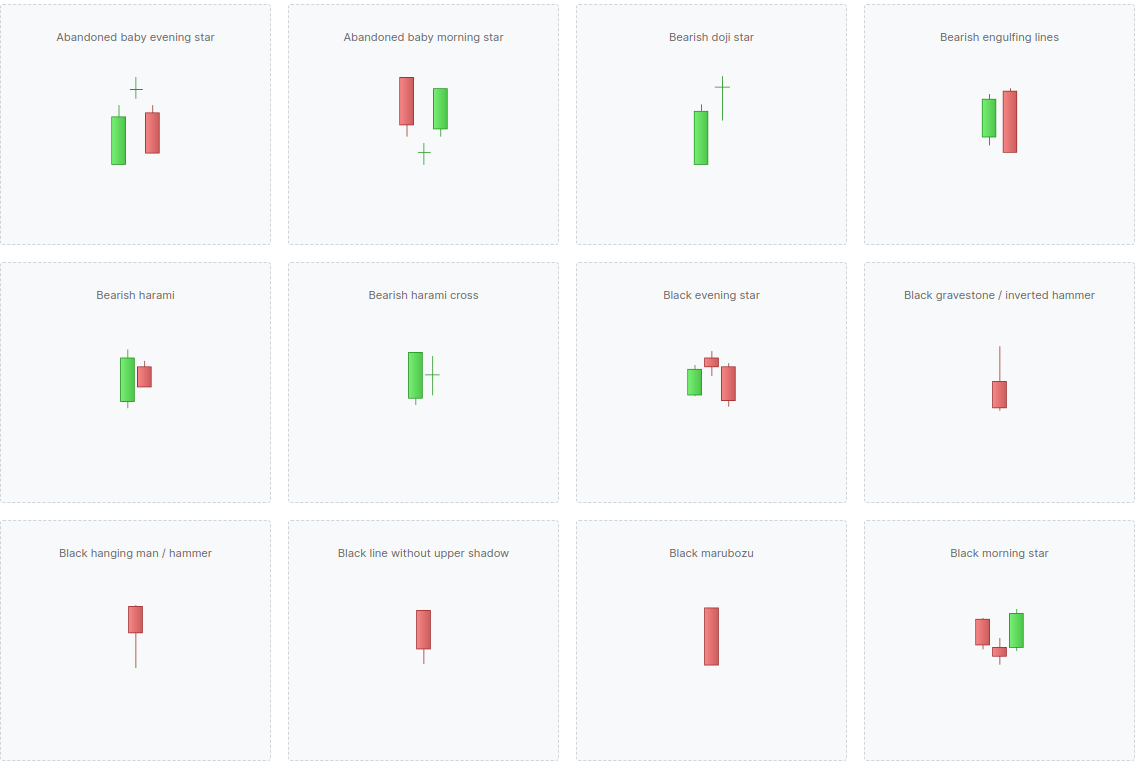

In [3]:
Image(filename="./../figures/cs_patterns.png")


[Source: https://www.prorealtime.com/en/help-manual/candlesticks-patterns]


## Loading and pre-processing the data

We can now proceed loading and analyzing data. We limit ourselves to a one stock case in this notebook to demonstrate the concepts and progress towards the whole investment universe in the next one.

**Note:** This notebook uses `yfinance` to download data directly, eliminating the need for pre-downloaded CSV files. The data is processed to match the format expected by the analysis functions.

We make use of helper functions that assist you in processing the data. The relevant functions can be imported like so:

     from BSquant import process_data
     from BSquant import cs_pattern_recognition

In software engineering there is the principle of `high cohesion` within functions, to enhance code maintainability. High cohesion means each function is dedicated to a single task, thereby reducing dependencies among different parts of the code. For example, in our case, data downloading is handled separately from preprocessing steps. This separation of concerns not only clarifies the code's structure but also simplifies future modifications and debugging.

Furthermore, it is crucial to document each function clearly. A well-crafted docstring should accompany every function, explaining its purpose, parameters, and return values. This practice not only aids your understanding but also assists your fellow researchers in grasping the functionality and intent of the code.

You can display a function's docstring by using the `help()` function and passing the function's name as an argument. Alternatively, to view a function's definition, you can utilize the `inspect` module.


In [4]:
help(process_data)  # displays the doc string of a function


Help on function process_data in module BSquant:

process_data(df: pandas.core.frame.DataFrame) -> pandas.core.frame.DataFrame
    Processes the given DataFrame by cleaning data, calculating intraday returns,
    and preparing for subsequent analysis.
    
    This function performs several steps:
    - Drops any rows with missing values.
    - Converts the volume column to integers.
    - Calculates the intraday return as (close - open) / open.
    - Determines the sign of the intraday return (positive, negative, or zero) as an integer.
    - Shifts the intraday returns and their signs to prepare for next-day return analysis.
    
    Parameters:
        df (pd.DataFrame): The DataFrame to process. Expects columns 'vol', 'open',
                           and 'close' to be present.
    
    Returns:
        pd.DataFrame: A DataFrame with the original data plus additional columns for
                      'intraday_return', 'sign_intraday_return', 'next_intraday_return',
              

In [5]:
print(inspect.getsource(process_data))  # displays the source code of a function


def process_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Processes the given DataFrame by cleaning data, calculating intraday returns,
    and preparing for subsequent analysis.

    This function performs several steps:
    - Drops any rows with missing values.
    - Converts the volume column to integers.
    - Calculates the intraday return as (close - open) / open.
    - Determines the sign of the intraday return (positive, negative, or zero) as an integer.
    - Shifts the intraday returns and their signs to prepare for next-day return analysis.

    Parameters:
        df (pd.DataFrame): The DataFrame to process. Expects columns 'vol', 'open',
                           and 'close' to be present.

    Returns:
        pd.DataFrame: A DataFrame with the original data plus additional columns for
                      'intraday_return', 'sign_intraday_return', 'next_intraday_return',
                      and 'sign_next_day_return'. Rows with missing values after processing
 

### Downloading data using yfinance

We will download data directly from yfinance for a single stock. The data will be formatted to match the structure expected by the `process_data` function.


In [6]:
# Define parameters
ticker = 'MSFT'  # Change as needed (e.g., 'AAPL', 'GOOGL', 'AMZN')
start_date = '1992-01-01'  # Adjust date range as needed
end_date = '2022-12-31'  # Adjust date range as needed

print(f"Downloading data for {ticker} from {start_date} to {end_date}...")

# Download data with auto_adjust=True to get split-adjusted prices
data_raw = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)

# Handle MultiIndex columns if they exist
if isinstance(data_raw.columns, pd.MultiIndex):
    data_raw.columns = data_raw.columns.get_level_values(0)

# Reset index to make Date a column
data = data_raw.reset_index()

# Rename columns to match the format expected by process_data function
# process_data expects: 'open', 'high', 'low', 'close', 'vol', 'date'
data.rename(columns={
    'Date': 'date',
    'Open': 'open',
    'High': 'high',
    'Low': 'low',
    'Close': 'close',
    'Volume': 'vol'
}, inplace=True)

# Convert date to timezone-naive datetime
if pd.api.types.is_datetime64_any_dtype(data['date']):
    data['date'] = pd.to_datetime(data['date']).dt.tz_localize(None)
else:
    data['date'] = pd.to_datetime(data['date'])

# Add ticker column (optional, for consistency with multi-stock format)
data['ticker'] = ticker

print(f"Data downloaded: {len(data)} records")
print(f"Date range: {data['date'].min()} to {data['date'].max()}")
print(f"\nFirst few rows:")
print(data.head())


Data downloaded: 7809 records
Date range: 1992-01-02 00:00:00 to 2022-12-30 00:00:00

First few rows:
Price       date     close      high       low      open       vol ticker
0     1992-01-02  1.450783  1.460328  1.393515  1.409423  74265600   MSFT
1     1992-01-03  1.438058  1.453965  1.422150  1.450784  38246400   MSFT
2     1992-01-06  1.482598  1.498505  1.430102  1.441238  63057600   MSFT
3     1992-01-07  1.527140  1.530322  1.473054  1.482599  64363200   MSFT
4     1992-01-08  1.581227  1.600316  1.511232  1.514414  90763200   MSFT


The function `process_data` is tasked with processing data retrieved, with one of its key operations being the removal of rows containing `NaN` values. This method is notably aggressive and results in the loss of approximately 20% of the data across the entire dataset. To potentially reduce this loss, there are a few considerations:

- Data provider inquiry: Inquiring with the data provider about the missing data may provide clues into the nature of these gaps. In scenarios like exchange outages or other reasons for missing records, accurately reconstructing the exact historical data is highly unlikely, if not impossible.

- Data interpolation: Another strategy is to interpolate missing values. However, this comes with caveats. Any form of interpolation will alter the final analysis outcomes. The difficulties of error propagation through interpolated data is considerable, making it a difficult process to assess how these changes impact overall results.

Also, in `process_data`, we employ `method chaining` with `Pandas`, which offers several advantages for managing and transforming dataframes. Method chaining allows for operations to be applied sequentially without modifying the original dataset, preserving the raw data unless explicitly overwritten. This approach is made possible by passing the dataframe from one operation to the next, with each method call returning a new dataframe upon which subsequent operations can act. One of the benefits of method chaining is enhanced readability and maintainability of the code. It presents the data processing workflow in a clear, step-by-step manner, making it easier to understand and modify the processing sequence at later stages.

It is important to note that method chaining relies on each operation returning a modified copy of the dataframe. Therefore, operations that return `None` disrupt the chain, leading to undesired behavior.

We proceed to calculate `intraday returns` as well as their sign. An intraday return is defined as follows:

$$
intraday\_return_t = \frac{close_t - open_t}{open_t} = \frac{close_t}{open_t} - 1
$$

It is important to note that intraday returns are defined differently from `daily returns`. While intraday returns are calculated by comparing the closing and opening prices within the same trading day, daily returns typically consider only the closing prices across consecutive days:

$$
daily\_return_t = \frac{close_t - close_{t-1}}{close_{t-1}} = \frac{close_t}{close_{t-1}} - 1
$$

The `shift` operator is utilised to align intraday returns at times $t$ and $t+1$. This alignment allows us to transparently evaluate the accuracy of predictions made by our candlestick patterns against the actual intraday returns observed in the market on the following day. By examining whether the signed returns at $t+1$ conform to the predictions, we can assess the effectiveness of our model.

Please note that the DataFrame retains certain information which, while not immediately necessary for this project, is beneficial for future analyses. This includes the precise numeric values of intraday returns, the volume of stocks traded, and the price volume for the day. Such details are important for conducting regression-type econometric studies on return series and for calculating the `Volume Weighted Average Price (VWAP)`.

Let us now process the downloaded data:


In [7]:
df = process_data(df=data)
print(f"Processed data shape: {df.shape}")
print(f"\nProcessed data columns: {df.columns.tolist()}")
df.head(5)


Processed data shape: (7808, 11)

Processed data columns: ['date', 'close', 'high', 'low', 'open', 'vol', 'ticker', 'intraday_return', 'sign_intraday_return', 'next_intraday_return', 'sign_next_day_return']


Price,date,close,high,low,open,vol,ticker,intraday_return,sign_intraday_return,next_intraday_return,sign_next_day_return
0,1992-01-02,1.450783,1.460328,1.393515,1.409423,74265600,MSFT,0.029345,1,-0.008772,-1
1,1992-01-03,1.438058,1.453965,1.422150,1.450784,38246400,MSFT,-0.008772,-1,0.028697,1
2,1992-01-06,1.482598,1.498505,1.430102,1.441238,63057600,MSFT,0.028697,1,0.030043,1
3,1992-01-07,1.527140,1.530322,1.473054,1.482599,64363200,MSFT,0.030043,1,0.044118,1
4,1992-01-08,1.581227,1.600316,1.511232,1.514414,90763200,MSFT,0.044118,1,0.024145,1


# Displaying price data in candlestick form

In this section, we explore how to plot candlestick charts in Python. While plotting data for extensive analysis is cumbersome (imagine plotting several years of data for 500 stocks), we will primarily rely on computation to assess the effectiveness of candlestick patterns. Nonetheless, for a small subset of data and for illustrative purposes, visualizing candlestick charts remains a worthwhile exercise.

We will examine two methods:

1. An efficient (yet less aesthetic) method using an `np.array` and `matplotlib`.
2. A more aesthetic (but less efficient) method using a `pd.DataFrame` and `plotly`.

## Efficient (and less aesthetic) method using an `np.array` and `matplotlib`

The function `ohlc_plot_candles_mpl` utilizes only OHLC (Open, High, Low, Close) data. This data is selected from our processed DataFrame, and a lookback period is specified. As discussed in the section "Anatomy of a Candlestick (aka Japanese Candlesticks)," we denote bullish days in green and bearish days in red, with upper and lower wicks marked in black.


In [8]:
def ohlc_plot_candles_mpl(data: np.array, window: int) -> plt.Figure:
    """
    Plotting OHLC data using an np.array (modified after https://github.com/sofienkaabar/mastering-financial-pattern-recognition/blob/main/Master_Function_MFPR.py)
    """
    plt.figure(figsize=(10, 10))
    sample = data[-window:,]

    for i in range(len(sample)):
        plt.vlines(
            x=i, ymin=sample[i, 2], ymax=sample[i, 1], color="black", linewidth=1
        )
        if sample[i, 3] > sample[i, 0]:
            plt.vlines(
                x=i, ymin=sample[i, 0], ymax=sample[i, 3], color="green", linewidth=1
            )
        if sample[i, 3] < sample[i, 0]:
            plt.vlines(
                x=i, ymin=sample[i, 3], ymax=sample[i, 0], color="red", linewidth=1
            )
        if sample[i, 3] == sample[i, 0]:
            plt.vlines(
                x=i,
                ymin=sample[i, 3],
                ymax=sample[i, 0] + 0.00005,
                color="black",
                linewidth=1.00,
            )
    plt.title("Price of selected asset displayed as candlestick chart")
    plt.xlabel("data points [daily frequency]")
    plt.ylabel("price [currency the stock is priced in]")
    plt.grid()
    plt.show()


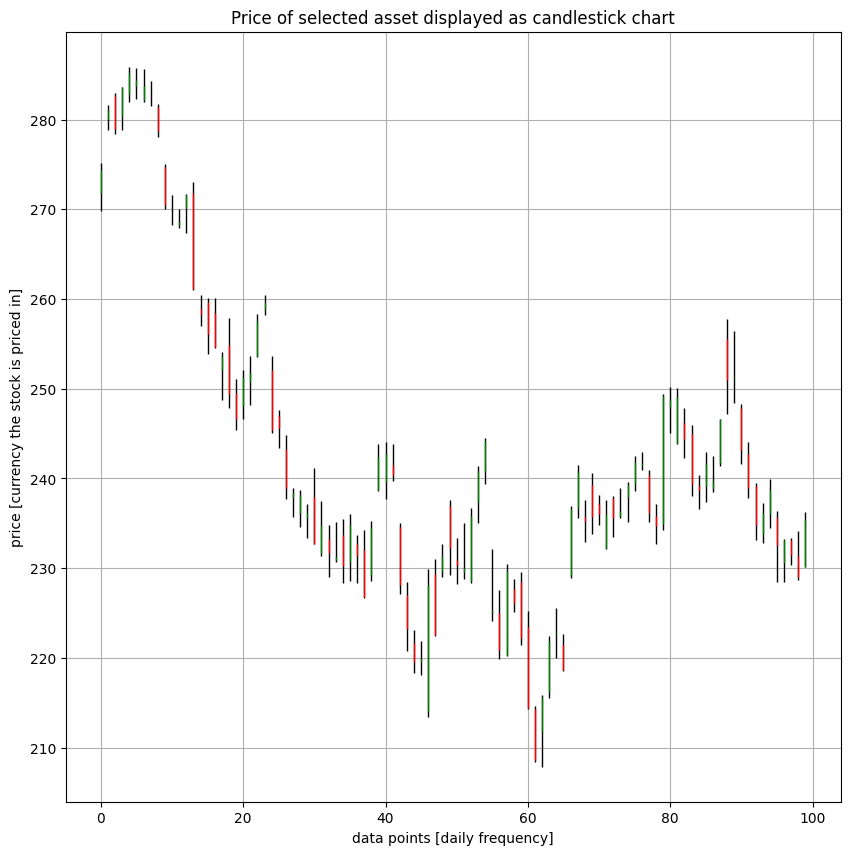

In [9]:
ohlc_plot_candles_mpl(data=df[["open", "high", "low", "close"]].values, window=100)


## More aesthetic (but less efficient) method using a `pd.DataFrame` and `plotly`

The second method employs `plotly`, a library renowned for producing publication-ready, interactive plots that are especially useful within a `Jupyter notebook` environment. While `plotly` is more complex and less memory-efficient than `matplotlib`, it excels in creating visually appealing charts suitable for a limited dataset. The general recommendation is to prototype with `matplotlib` due to its simplicity and efficiency, and then switch to `plotly` for presenting final results.

To utilize this method, we supply the OHLC data in a `DataFrame`, with an additional requirement for the `date` column. This inclusion is crucial for accurately formatting the date on the x-axis. Furthermore, it necessitates setting the `DataFrame's` index to the date column, which should contain datetime objects. Additionally, for improved visibility, we constrain the `DataFrame` to display only the most recent 100 days of data.


In [10]:
def ohlc_plot_candles_plotly(df: pd.DataFrame) -> go.Figure:
    fig = go.Figure(
        data=[
            go.Candlestick(
                x=df.index,
                open=df["open"],
                high=df["high"],
                low=df["low"],
                close=df["close"],
            )
        ]
    )

    fig.update_layout(
        font={"size": 18},
        legend={
            "yanchor": "top",
            "y": 0.99,
            "xanchor": "right",
            "x": 0.99,
            "font": {"size": 20},
        },
        title="Price of selected asset displayed as candlestick chart",
        xaxis_title="date [daily frequency]",
        yaxis_title="price [currency the stock is priced in]",
        autosize=False,
        width=800,
        height=800,
    )

    fig.show()


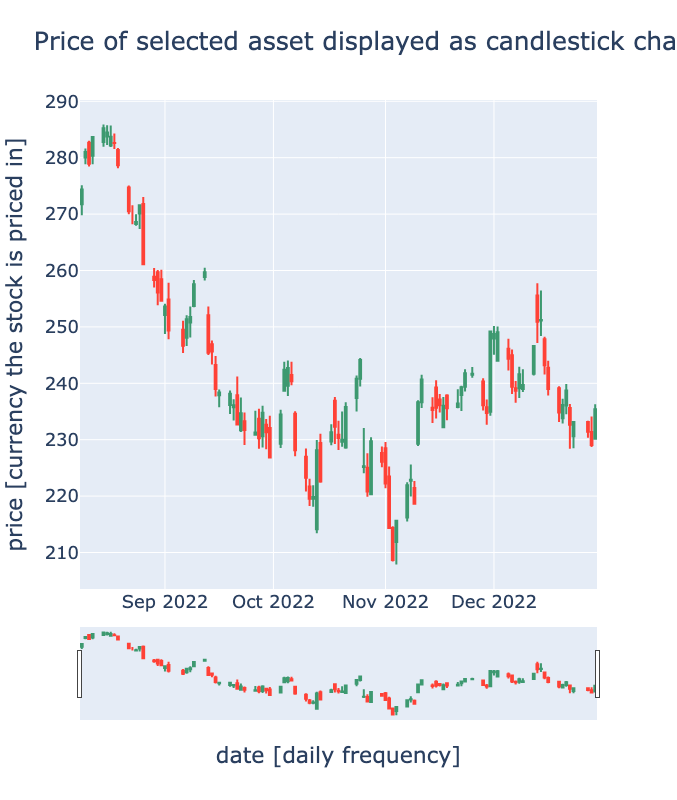

In [11]:
ohlc_plot_candles_plotly(
    df=df[["date", "open", "high", "low", "close"]].set_index("date")[-100:]
)


# What candlestick patterns are available?

Having understood the visual aspects of candlestick patterns, our next step is to identify these patterns within financial data. Fortunately, we have access to `talib`, a pattern recognition library written in `C++`. Its efficiency not only provides convenience but also spares us the considerable effort of manually coding these patterns, a task that could easily constitute a Bachelor's or even Master's thesis.

`talib` is proficient in detecting candlestick patterns, indicating not only their occurrence but also classifying them as bearish or bullish. The library is capable of recognizing 63 distinct candlestick patterns. For example, the first five patterns include `2 Crows`, `3 Black Crows`, `3 Inside`, `3 Line Strike`, and `3 Outside`. While the names of these patterns are a topic on their own for enthusiasts, our focus is on the signals they provide and whether the subsequent intraday returns align with their predictions.

The function `cs_pattern_recognition` living within `BSquant.py` is instrumental in performing candlestick pattern recognition, utilizing our previously processed data as its input. This function generates a multi-index DataFrame, where the primary index corresponds to the identified candlestick pattern, and the secondary index represents the date on which the pattern occurred. The use of multi-index DataFrames is highly recommended for those interested in delving deeper into advanced data science techniques. While this notebook will guide you through the necessary steps to achieve our specific analytical goals, it is worth noting that our discussion on the functionalities offered by multi-indexed DataFrames is not comprehensive.

Recall you can access the docstring as well as the sourcecode yourself by invoking:
```python
help(cs_pattern_recognition)
print(inspect.getsource(cs_pattern_recognition))
```


In [12]:
candle_names = talib.get_function_groups()["Pattern Recognition"]
print(f"Total candlestick patterns available: {len(candle_names)}")
print(f"\nFirst 10 patterns: {candle_names[:10]}")


Total candlestick patterns available: 61

First 10 patterns: ['CDL2CROWS', 'CDL3BLACKCROWS', 'CDL3INSIDE', 'CDL3LINESTRIKE', 'CDL3OUTSIDE', 'CDL3STARSINSOUTH', 'CDL3WHITESOLDIERS', 'CDLABANDONEDBABY', 'CDLADVANCEBLOCK', 'CDLBELTHOLD']


In [13]:
# The result of the pattern recognition will be a multi-indexed DataFrame
cs_signals_df = cs_pattern_recognition(df=df)
print(f"Pattern recognition complete. Found {len(cs_signals_df)} pattern instances.")
if len(cs_signals_df) > 0:
    cs_signals_df.head(10)
else:
    print("No patterns detected.")


Pattern recognition complete. Found 15473 pattern instances.


In [14]:
# We can query a specific candlestick pattern from a multiindex data frame like so.
# The multi-index DataFrame will then be a simple DataFrame.
# You can imagine multi-index DataFrames to be a multidimensional data structure
# projected onto 2D space.
if len(cs_signals_df) > 0:
    first_pattern = cs_signals_df.index.get_level_values('candle')[0]
    print(f"Example: Querying pattern '{first_pattern}':")
    cs_signals_df.loc[first_pattern].head()


Example: Querying pattern 'CDL2CROWS':


## Performance evaluation of a binary classifier: The confusion matrix

A confusion matrix is a table that quantifies and summarizes the performance of a classification algorithm, offering a visual representation of the algorithm's accuracy. This matrix is particularly useful in binary classification to evaluate the effectiveness of a trading algorithm. It comprises four key metrics:

- **TP (True Positive)**: This metric counts the number of instances correctly identified as positive by the algorithm. In the context of trading, it represents the days correctly predicted to be profitable, where acting on the algorithm's signal results in a gain.

- **TN (True Negative)**: TN counts the days correctly identified as negative, where the trading algorithm correctly signals not to trade. These are the instances where inactivity based on the algorithm's advice is beneficial, avoiding losses.

- **FP (False Positive)**: Also known as Type I error, FP represents the instances where the algorithm incorrectly signals a positive outcome. In trading, this means entering a trade expecting a profit when the market actually moves in the opposite direction, resulting in a loss.

- **FN (False Negative)**: Known as Type II error, FN represents missed opportunities—days the algorithm failed to signal a positive outcome when the market did move beneficially. These are instances where the algorithm's silence or negative prediction prevents participation in a profitable trade.

These four components of the confusion matrix allow traders and analysts to assess the reliability and errors of their trading algorithms, quantifying their predictive capabilities, misses and, consequently, areas for improvement.

Performance metrics derived from a confusion matrix, such as `accuracy`, `precision`, `recall`, and the `F1 score`, provide a comprehensive evaluation of an algorithm's effectiveness. These metrics are defined as follows:

- **Accuracy**: This metric measures the overall correctness of the algorithm and is calculated as the ratio of correctly classified trading days (TP + TN) to the total number of trading days (TP + TN + FP + FN). It reflects the algorithm's ability to correctly identify both profitable and non-profitable trading days.

- **Precision**: Precision assesses the algorithm's accuracy in predicting profitable trading days. It is represented as the ratio of correctly predicted profitable days (TP) to the total number of days predicted as profitable (TP + FP). This metric emphasizes the quality of the positive predictions.

- **Recall (Sensitivity)**: Recall measures the algorithm's ability to identify actual profitable trading days. It is defined as the ratio of correctly predicted profitable days (TP) to the total number of actual profitable days (TP + FN). Recall, therefore, focuses on the algorithm's capability to capture all potential profitable opportunities.

For further information on confusion matrices, see:
- https://www.kdnuggets.com/2020/01/guide-precision-recall-confusion-matrix.html
- https://towardsdatascience.com/performance-metrics-confusion-matrix-precision-recall-and-f1-score-a8fe076a2262


Given the varying frequencies of candlestick pattern occurrences, we further refine our analysis by applying the `Wilson score` to adjust the precision metric according to the frequency of each pattern's occurrence, along with calculating their 95% confidence interval. This adjustment is relevant because it accounts for the variability in pattern frequencies, providing a more reliable measure of precision.

For a candlestick signal to be considered statistically significant, its lower confidence boundary must exceed the 50% threshold. The further this lower bound is above 50%, the higher our confidence in the potential profitability of the signal. This method ensures that we prioritize signals not just on their precision, but also on the statistical confidence in their predictive power.

More precisely, the Wilson score interval for a proportion is given by:

$$
\text{Center} = \frac{\hat{p} + \frac{z^2}{2n}}{1 + \frac{z^2}{n}}
$$

$$
\text{Margin} = \frac{z \sqrt{\frac{\hat{p}(1 - \hat{p})}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}
$$

$$
\text{CI Lower Bound} = \text{Center} - \text{Margin}
$$

$$
\text{CI Upper Bound} = \text{Center} + \text{Margin}
$$

where:
- $\hat{p}$ is the observed proportion (e.g., precision)
- $z$ is the z-score corresponding to the desired confidence level (1.96 for 95% confidence)
- $n$ is the total number of instances (e.g., TP + FP)

The Wilson score interval is useful when the sample size is small or when the proportion is near 0 or 1. Unlike the normal approximation interval, the Wilson interval does not produce probabilities outside the [0, 1] range and adjusts the observed proportion by a factor related to the confidence level and sample size, providing a more accurate confidence interval for proportions.


In [15]:
performance_metrics = cs_performance(cs_signals_df)
print(f"Performance metrics calculated for {len(performance_metrics)} patterns")
performance_metrics.head(10)


Performance metrics calculated for 56 patterns


Price,TP,FP,total_instances,precision,center,margin,ci_upper,ci_lower,TP_wilson
candle,,,,,,,,,
CDLLONGLINE,755,891,1646,0.458688,0.458784,0.024044,0.482828,0.434740,0.458784
CDLSPINNINGTOP,802,834,1636,0.490220,0.490243,0.024195,0.514438,0.466047,0.490243
CDLBELTHOLD,588,647,1235,0.476113,0.476187,0.027811,0.503998,0.448376,0.476187
CDLCLOSINGMARUBOZU,523,658,1181,0.442845,0.443030,0.028284,0.471314,0.414746,0.443030
CDLDOJI,491,521,1012,0.485178,0.485234,0.030734,0.515968,0.454500,0.485234
CDLLONGLEGGEDDOJI,491,521,1012,0.485178,0.485234,0.030734,0.515968,0.454500,0.485234
CDLHIGHWAVE,474,513,987,0.480243,0.480320,0.031108,0.511428,0.449211,0.480320
CDLHIKKAKE,462,479,941,0.490967,0.491004,0.031876,0.522880,0.459127,0.491004
CDLSHORTLINE,419,477,896,0.467634,0.467772,0.032601,0.500373,0.435171,0.467772


We aim to delve into the performance metrics by examining candlestick signals from two perspectives: the total number of instances and those instances where the Wilson-corrected true positive score exceeds 50%. Moreover, for every candlestick pattern, we plan to display the Wilson-corrected true positive score along with their 95% uncertainty interval in a bar chart. This chart will also demarcate trading zones in red, yellow, and green, as follows:

- **Red Zone**: Signals with a true positive score significantly below the 50% threshold are deemed to lack informational content. In fact, such signals are considered contraindicators, suggesting a course of action opposite to what they indicate.

- **Yellow Zone**: True positive scores ranging between 50% and 55% fall into this category. These signals are potential candidates for further exploration, as they might possess some predictive value.

- **Green Zone**: Signals with performance metrics exceeding 55% are regarded as informative, suggesting that they could provide a reliable basis for trading decisions.

This approach allows us to systematically assess the reliability of candlestick patterns in forecasting market movements. By categorizing signals into these zones based on their Wilson-corrected true positive scores, we can more effectively identify patterns that are likely to trigger trading action.


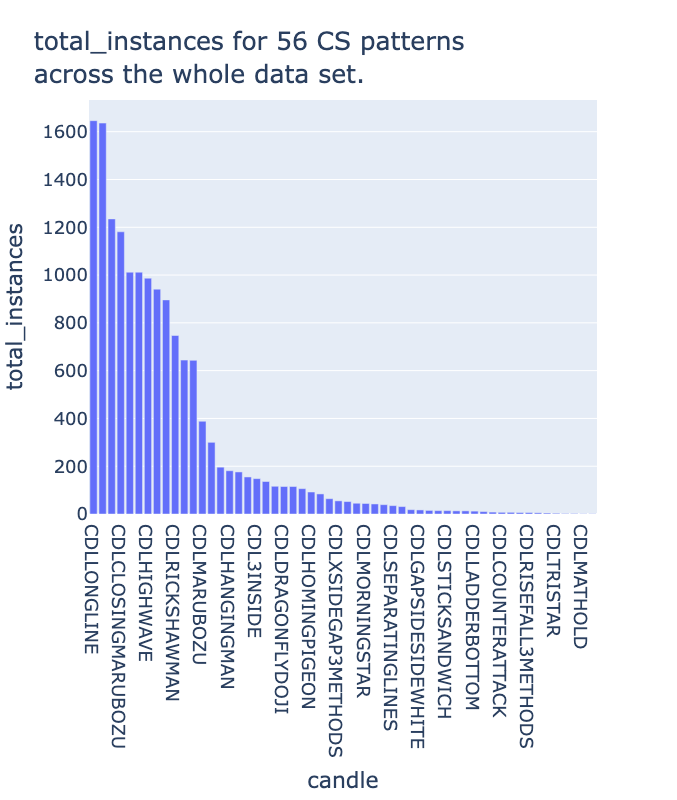

In [16]:
# Plot all patterns, ranked by number of instances
plot_cs_performance(
    df=performance_metrics,
    criterion="total_instances",
    title_suffix="across the whole data set.",
)


In [17]:
# Plot the patterns, ranked by number of instances, with a true-positive rate >50%.
significant_patterns = performance_metrics.query("ci_lower > 0.5")
if len(significant_patterns) > 0:
    plot_cs_performance(
        df=significant_patterns.sort_values(by="total_instances", ascending=False),
        criterion="total_instances",
        title_suffix="with ci_lower > 50%.",
    )
else:
    print("No patterns found with ci_lower > 50%.")


No patterns found with ci_lower > 50%.


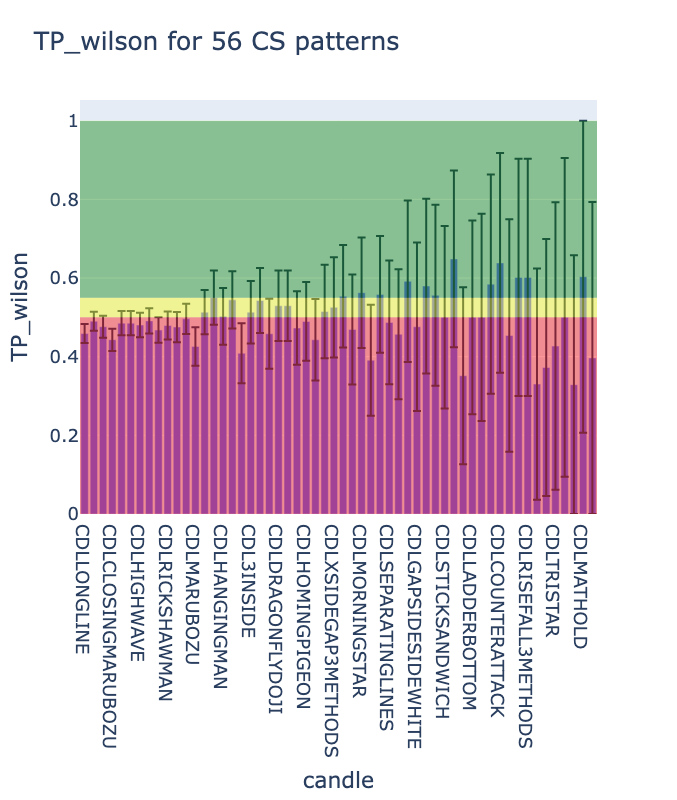

In [18]:
# Plot patterns ranked by Wilson score with performance zones
plot_cs_performance(
    df=performance_metrics, criterion="TP_wilson", plot_performance=True
)


## Trading Strategy Performance

Now let's evaluate the performance of a trading strategy based on candlestick patterns. We can compare a naive buy-and-hold strategy against a strategy that uses candlestick signals.


In [19]:
# Buy-and-hold strategy performance
buy_hold_performance = compute_trading_strategy_performance(df=df, verbose=True)


Annualised strategy return [%]: 0.0960
Annualised strategy standard deviation of returns [%]: 0.2638
Sharpe ratio of strategy: 0.3638


In [20]:
# Naive candlestick strategy: sum all signals for each day
# Create trading signals based on candlestick patterns
if len(cs_signals_df) > 0:
    # Sum all candlestick signals for each date
    trading_signal = (
        cs_signals_df.query("cs_pattern != 0")
        .reset_index()
        .groupby("date")["cs_pattern"]
        .sum()
        .to_frame("signal")
    )
    
    # Filter out zero signals
    trading_signal = trading_signal[trading_signal["signal"] != 0]
    
    # Get returns for days following signals
    performance_trading_signals = df[
        df["date"].isin([date + pd.DateOffset(days=1) for date in trading_signal.index])
    ][["date", "intraday_return"]].copy()
    
    if len(performance_trading_signals) > 0:
        performance_trading_signals["account_curve"] = (
            1 + performance_trading_signals["intraday_return"]
        ).cumprod()
        performance_trading_signals["cumsumret"] = performance_trading_signals[
            "intraday_return"
        ].cumsum()
        
        print(f"Trading signals generated: {len(trading_signal)} days with signals")
        print(f"Days with returns following signals: {len(performance_trading_signals)}")
        
        cs_strategy_performance = compute_trading_strategy_performance(
            df=performance_trading_signals, verbose=True
        )
    else:
        print("No trading signals generated.")
else:
    print("No candlestick patterns detected.")


Trading signals generated: 5857 days with signals
Days with returns following signals: 4611
Annualised strategy return [%]: 0.0598
Annualised strategy standard deviation of returns [%]: 0.2620
Sharpe ratio of strategy: 0.2283


# Conclusion

This notebook demonstrated how to:

1. Download stock data directly using `yfinance`
2. Process the data to calculate intraday returns
3. Visualize price data as candlestick charts
4. Identify candlestick patterns using `talib`
5. Evaluate pattern performance using statistical metrics
6. Compare trading strategies based on candlestick signals

The analysis can be extended to multiple stocks (see notebook 3) or refined with machine learning techniques to improve pattern recognition and signal generation.


# END
